In [13]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
#!pip install "numpy<2.0" "pandas<3.0" "numba>=0.59" -U -q
#!pip install scanpy pyucell gseapy mygene -U -q

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mygene
import gseapy as gp

import pyucell as uc
import scanpy as sc
import anndata as ad

In [16]:
gene_degree = pd.read_csv('/content/drive/MyDrive/SSN/lioness_gene_degree_matrix.csv.gz', index_col=0)
print(gene_degree.shape)
print(gene_degree.head(3), '\n')
print(gene_degree.tail(3))

(18395, 517)
                 CS0001  CS0005  CS0008  CS0009  CS0010  CS0019  CS0023  \
ENSG00000000419       0      47      48       1       3       1       1   
ENSG00000002746       2       0     279       0       5       3       1   
ENSG00000001167       6       7       1       0      23       2       6   

                 CS0046  CS0049  CS0050  ...  I0341  I0521  I0467  I0125  \
ENSG00000000419       0       0       0  ...      0      2      0     11   
ENSG00000002746       0       1       2  ...      1      0      0      2   
ENSG00000001167       0       0       0  ...      0      2      0      0   

                 I0525  I0338  I0524  I0251  I0276  I0221  
ENSG00000000419      0      1      3      0      0     54  
ENSG00000002746      1     46      0      0     53      0  
ENSG00000001167      2      0      1      0      0      0  

[3 rows x 517 columns] 

                 CS0001  CS0005  CS0008  CS0009  CS0010  CS0019  CS0023  \
ENSG00000273173       0       0       0 

# Padronização

In [17]:
ids = gene_degree.index.tolist()

mg = mygene.MyGeneInfo()

result = mg.querymany(ids,
                      scopes='ensembl.gene',
                      fields='symbol',
                      species='human',
                      as_dataframe=True)

result.head(3)

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-18395 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing quer

,_id,_score,symbol,notfound
query,,,,
ENSG00000000419,8813,32.913440,DPM1,NaN
ENSG00000002746,23072,32.913612,HECW1,NaN
ENSG00000001167,4800,32.913616,NFYA,NaN


In [18]:
gene_degree['symbol'] = gene_degree.index.map(result['symbol'].to_dict())

gene_degree = gene_degree.dropna(subset='symbol')
gene_degree = gene_degree.drop_duplicates(subset='symbol')

gene_degree.set_index('symbol', inplace=True)
gene_degree.head()

,CS0001,CS0005,CS0008,CS0009,CS0010,CS0019,CS0023,CS0046,CS0049,CS0050,...,I0341,I0521,I0467,I0125,I0525,I0338,I0524,I0251,I0276,I0221
symbol,,,,,,,,,,,,,,,,,,,,,
DPM1,0,47,48,1,3,1,1,0,0,0,...,0,2,0,11,0,1,3,0,0,54
HECW1,2,0,279,0,5,3,1,0,1,2,...,1,0,0,2,1,46,0,0,53,0
NFYA,6,7,1,0,23,2,6,0,0,0,...,0,2,0,0,2,0,1,0,0,0
CYP51A1,7,85,0,0,0,0,33,0,2,33,...,35,9,8,1,0,0,0,0,3,2
CFTR,0,2,2,1,1,1,1,0,2,0,...,2,0,2,3,3,1,4,0,0,1


# Limpeza

In [19]:
print(gene_degree.shape)

# Caso exista qualquer valor diferente de zero, o gene é mantido
gene_degree = gene_degree.loc[ (gene_degree!=0).any(axis=1) ]
print(gene_degree.shape)

(18391, 517)
(18033, 517)


## Transformação para reduzir empates

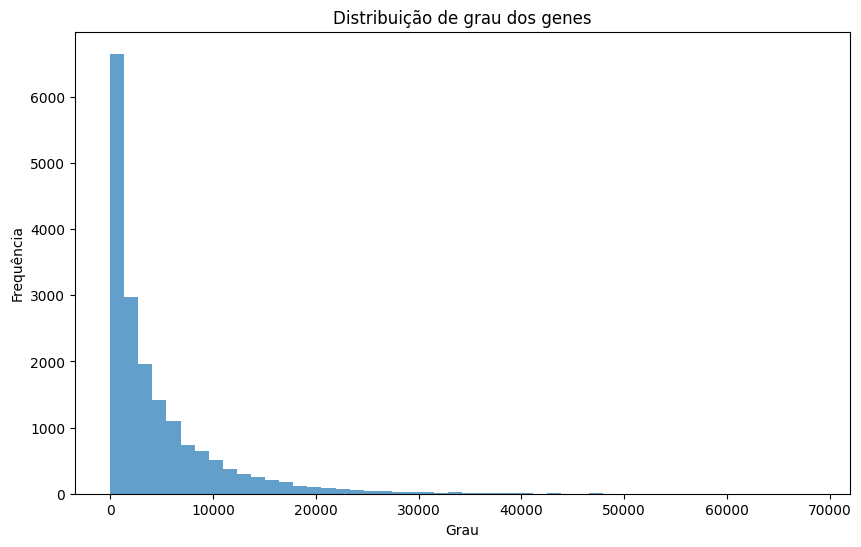

In [20]:
degree = gene_degree.sum(axis=1)

plt.figure(figsize=(10, 6))

plt.hist(degree, bins=50, alpha=0.7)
plt.title("Distribuição de grau dos genes")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.show()

In [21]:
gene_degree = np.log2(gene_degree + 1)

gene_degree.head(3)

,CS0001,CS0005,CS0008,CS0009,CS0010,CS0019,CS0023,CS0046,CS0049,CS0050,...,I0341,I0521,I0467,I0125,I0525,I0338,I0524,I0251,I0276,I0221
symbol,,,,,,,,,,,,,,,,,,,,,
DPM1,0.000000,5.584963,5.614710,1.0,2.000000,1.000000,1.000000,0.0,0.0,0.000000,...,0.0,1.584963,0.0,3.584963,0.000000,1.000000,2.0,0.0,0.000000,5.78136
HECW1,1.584963,0.000000,8.129283,0.0,2.584963,2.000000,1.000000,0.0,1.0,1.584963,...,1.0,0.000000,0.0,1.584963,1.000000,5.554589,0.0,0.0,5.754888,0.00000
NFYA,2.807355,3.000000,1.000000,0.0,4.584963,1.584963,2.807355,0.0,0.0,0.000000,...,0.0,1.584963,0.0,0.000000,1.584963,0.000000,1.0,0.0,0.000000,0.00000


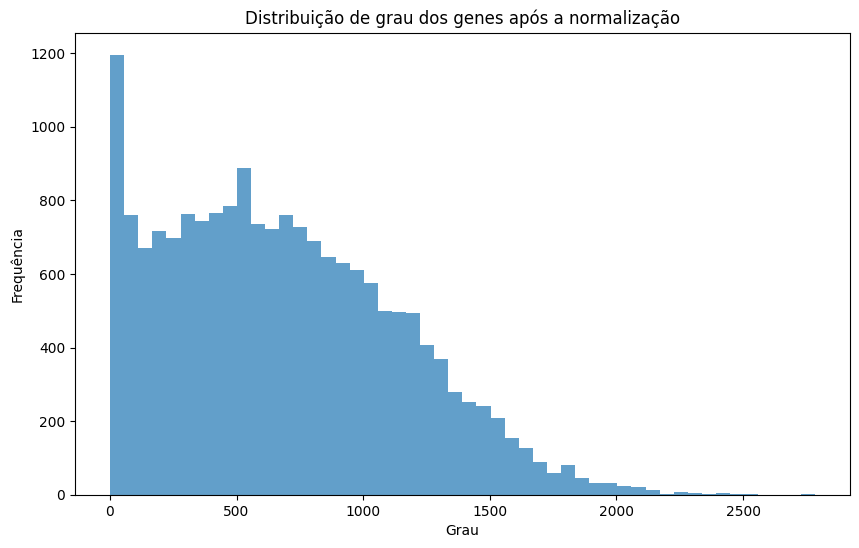

In [22]:
degree = gene_degree.sum(axis=1)

plt.figure(figsize=(10, 6))

plt.hist(degree, bins=50, alpha=0.7)
plt.title("Distribuição de grau dos genes após a normalização")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.show()

Quanto maior o valor, maior o grau do gene indicado

# Procurando Gene Sets

In [23]:
gene_sets = gp.get_library(name='KEGG_2021_Human', organism='Human')
print(list(gene_sets.keys())[:3])

['ABC transporters', 'AGE-RAGE signaling pathway in diabetic complications', 'AMPK signaling pathway']


In [43]:
adata = ad.AnnData(
    X=gene_degree.T.values.copy().astype(np.float32),
    obs=pd.DataFrame(index=gene_degree.columns),
    var=pd.DataFrame(index=gene_degree.index)
)

uc.compute_ucell_scores(adata, signatures=gene_sets)

scores = adata.obs
scores.head()

/usr/local/lib/python3.12/dist-packages/pyucell/scoring.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"{sig_name}{suffix}"] = scores_all[:, j]
/usr/local/lib/python3.12/dist-packages/pyucell/scoring.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f"{sig_name}{suffix}"] = scores_all[:, j]
/usr/local/lib/python3.12/dist-packages/pyucell/scoring.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance. 

,ABC transporters_UCell,AGE-RAGE signaling pathway in diabetic complications_UCell,AMPK signaling pathway_UCell,Acute myeloid leukemia_UCell,Adherens junction_UCell,Adipocytokine signaling pathway_UCell,Adrenergic signaling in cardiomyocytes_UCell,African trypanosomiasis_UCell,"Alanine, aspartate and glutamate metabolism_UCell",Alcoholism_UCell,...,Vitamin digestion and absorption_UCell,Wnt signaling pathway_UCell,Yersinia infection_UCell,alpha-Linolenic acid metabolism_UCell,beta-Alanine metabolism_UCell,cAMP signaling pathway_UCell,cGMP-PKG signaling pathway_UCell,mRNA surveillance pathway_UCell,mTOR signaling pathway_UCell,p53 signaling pathway_UCell
CS0001,0.064019,0.086975,0.099849,0.135815,0.113436,0.116862,0.046131,0.042557,0.107250,0.069638,...,0.030588,0.076682,0.117630,0.025178,0.077085,0.068405,0.053042,0.047042,0.082035,0.072323
CS0005,0.039449,0.091645,0.060154,0.160321,0.111762,0.066785,0.070607,0.024874,0.000000,0.091388,...,0.029132,0.087510,0.088137,0.000000,0.087033,0.065813,0.040897,0.117180,0.104522,0.025253
CS0008,0.043000,0.100690,0.085632,0.129106,0.132783,0.070841,0.103924,0.011844,0.048598,0.083556,...,0.038067,0.082564,0.060378,0.000000,0.118424,0.071402,0.091203,0.084974,0.084687,0.133709
CS0009,0.105003,0.074405,0.103925,0.095366,0.108193,0.079220,0.086917,0.017209,0.079128,0.100329,...,0.028375,0.065004,0.069070,0.001910,0.190502,0.082362,0.064418,0.083715,0.085340,0.053081
CS0010,0.104386,0.094743,0.053832,0.041335,0.121902,0.063788,0.098098,0.044291,0.017099,0.077658,...,0.000000,0.121664,0.048856,0.000000,0.084765,0.072717,0.078225,0.047682,0.071782,0.083362


In [44]:
#scores.to_csv('ucell_scores.csv')